# Neural Networks from Scratch: MNIST

**Learning objectives**
- Load and preprocess MNIST
- Implement batched forward propagation with ReLU + softmax
- Derive categorical cross-entropy backpropagation
- Visualize learned weights and misclassifications
- Compare with PyTorch `CrossEntropyLoss`

**Prerequisite:** Work through `xor-neural-network.ipynb` first.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

np.random.seed(42)

# --- Hyperparameters (tweak these) ---
HIDDEN_SIZE = 128
LEARNING_RATE = 0.5
EPOCHS = 25
BATCH_SIZE = 64
TRAIN_SIZE = 10_000   # subsample for speed; increase for higher accuracy
TEST_SIZE = 2_000

## 1. Problem setup

MNIST: 28×28 grayscale images of handwritten digits (0–9).

We use a **subset** for the NumPy scratch section (~2–5 min on CPU). Increase `TRAIN_SIZE` toward 60,000 for full-dataset accuracy.

In [2]:
print('Downloading MNIST from OpenML (first run only)...')
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='liac-arff')
X_all = mnist.data.astype(np.float64)
y_all = mnist.target.astype(np.int64)

# Normalize to [0, 1]
X_all /= 255.0

# Train/test split (last 10k in OpenML is standard test set)
X_train_full, X_test_full = X_all[:60_000], X_all[60_000:]
y_train_full, y_test_full = y_all[:60_000], y_all[60_000:]

# Subsample
rng = np.random.default_rng(42)
train_idx = rng.choice(len(X_train_full), TRAIN_SIZE, replace=False)
test_idx = rng.choice(len(X_test_full), TEST_SIZE, replace=False)
X_train, y_train = X_train_full[train_idx], y_train_full[train_idx]
X_test, y_test = X_test_full[test_idx], y_test_full[test_idx]

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (10000, 784), Test: (2000, 784)


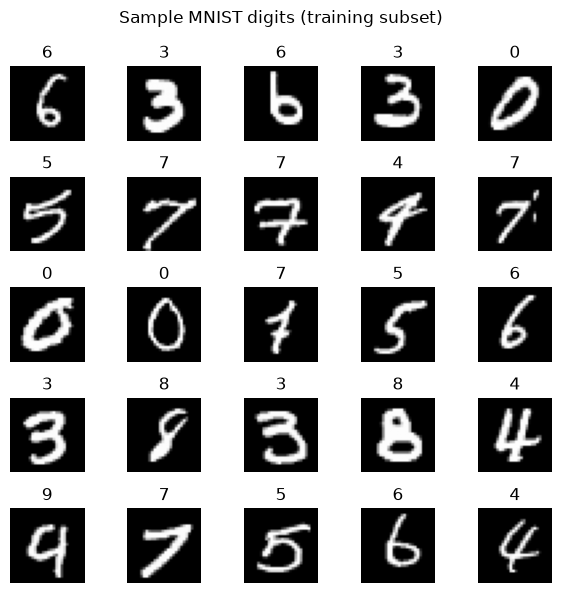

In [3]:
def one_hot(y, num_classes=10):
    Y = np.zeros((len(y), num_classes))
    Y[np.arange(len(y)), y] = 1.0
    return Y

Y_train = one_hot(y_train)
Y_test = one_hot(y_test)

fig, axes = plt.subplots(5, 5, figsize=(6, 6))
for ax, i in zip(axes.ravel(), rng.choice(len(X_train), 25, replace=False)):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(str(y_train[i]))
    ax.axis('off')
plt.suptitle('Sample MNIST digits (training subset)')
plt.tight_layout()
plt.show()

## 2. Architecture

```
Input (784)  →  Hidden (128, ReLU)  →  Output (10, softmax)
```

- **ReLU** hidden: $A^{[1]} = \max(0, Z^{[1]})$ — avoids vanishing gradients better than sigmoid in deeper/wider nets
- **Softmax** output: converts logits to a probability distribution over 10 digits

Weight shapes:
- $W^{[1]}$: `(784, 128)`, $W^{[2]}$: `(128, 10)`

In [4]:
def init_params(n_x=784, n_h=HIDDEN_SIZE, n_y=10):
    # He-style init for ReLU
    W1 = np.random.randn(n_x, n_h) * np.sqrt(2.0 / n_x)
    b1 = np.zeros((1, n_h))
    W2 = np.random.randn(n_h, n_y) * np.sqrt(2.0 / n_h)
    b2 = np.zeros((1, n_y))
    return W1, b1, W2, b2

## 3. Forward propagation (batched)

For a mini-batch $X$ of shape `(batch, 784)`:

$$Z^{[1]} = X W^{[1]} + b^{[1]}, \quad A^{[1]} = \mathrm{ReLU}(Z^{[1]})$$
$$Z^{[2]} = A^{[1]} W^{[2]} + b^{[2]}, \quad A^{[2]} = \mathrm{softmax}(Z^{[2]})$$

**Numerically stable softmax:** subtract row-wise max before `exp`.

In [5]:
def relu(Z):
    return np.maximum(0, Z)

def softmax(Z):
    # Z: (batch, classes)
    shifted = Z - np.max(Z, axis=1, keepdims=True)
    expZ = np.exp(shifted)
    return expZ / np.sum(expZ, axis=1, keepdims=True)

def forward(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = softmax(Z2)
    cache = (X, Z1, A1, Z2, A2)
    return A2, cache

# Smoke test on one batch
W1, b1, W2, b2 = init_params()
batch = X_train[:BATCH_SIZE]
A2, cache = forward(batch, W1, b1, W2, b2)
print('Shapes:', batch.shape, cache[2].shape, A2.shape)
print('Softmax rows sum to 1:', np.allclose(A2.sum(axis=1), 1.0))

Shapes: (64, 784) (64, 128) (64, 10)
Softmax rows sum to 1: True


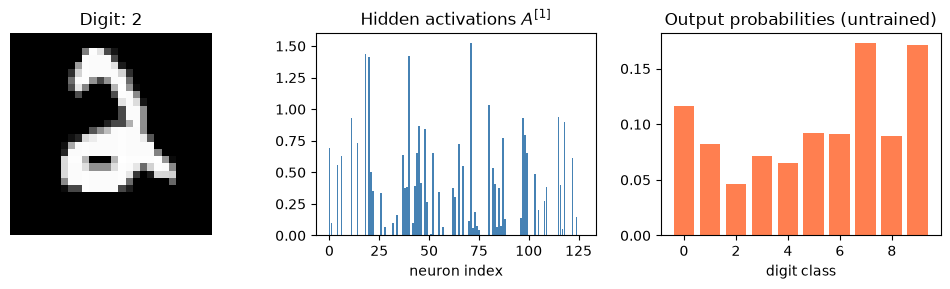

In [6]:
# Hidden activation heatmap for one digit
idx = 0
A2, cache = forward(X_train[idx:idx+1], W1, b1, W2, b2)
_, Z1, A1, _, A2 = cache

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(X_train[idx].reshape(28, 28), cmap='gray')
axes[0].set_title(f'Digit: {y_train[idx]}')
axes[0].axis('off')
axes[1].bar(range(HIDDEN_SIZE), A1.ravel(), color='steelblue')
axes[1].set_title('Hidden activations $A^{[1]}$')
axes[1].set_xlabel('neuron index')
axes[2].bar(range(10), A2.ravel(), color='coral')
axes[2].set_title('Output probabilities (untrained)')
axes[2].set_xlabel('digit class')
plt.tight_layout()
plt.show()

### Pause & Reflect — Forward propagation

1. Why subtract the max before softmax?
2. What does it mean if one output probability is ~0.9 before training?
3. Why ReLU instead of sigmoid in the hidden layer?

### Discussion — Forward propagation

1. **Max subtraction**: Prevents `exp(large)` overflow; softmax result is unchanged because $\frac{e^{z_i}}{\sum e^{z_j}}$ is shift-invariant.
2. **High prob before training**: Mostly **random luck** from init — not evidence the network has learned that class.
3. **ReLU**: Gradient is 1 for positive inputs (no saturation on the active side), training is faster than sigmoid for hidden layers.

## 4. Cost function (categorical cross-entropy)

For one-hot labels $Y$ and predictions $\hat{Y}$:

$$L = -\frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{10} Y_{ik} \log(\hat{Y}_{ik})$$

Only the true class column contributes (others are multiplied by 0).

In [7]:
def compute_loss(Y, A2):
    eps = 1e-8
    A2_clip = np.clip(A2, eps, 1.0)
    per_sample = -np.sum(Y * np.log(A2_clip), axis=1)
    return float(np.mean(per_sample))

Y_batch = Y_train[:BATCH_SIZE]
A2_batch, _ = forward(X_train[:BATCH_SIZE], W1, b1, W2, b2)
print(f'Loss on first batch (untrained): {compute_loss(Y_batch, A2_batch):.4f}')

Loss on first batch (untrained): 2.4023


### Pause & Reflect — Cost function

1. What is the loss if the model assigns uniform probability $0.1$ to each class?
2. How does this generalize the XOR binary cross-entropy?
3. Why one-hot encode instead of using integer labels directly in the loss?

### Discussion — Cost function

1. **Uniform**: $-\log(0.1) \approx 2.30$ per sample — high uncertainty across 10 classes.
2. **Generalization**: BCE is the 2-class special case; categorical CE sums over all classes.
3. **One-hot**: Makes the gradient $\hat{Y} - Y$ clean and vectorized; integer labels need indexing/gather ops.

## 5. Backpropagation

With **softmax + categorical cross-entropy**, the output error is again elegant:

$$\delta^{[2]} = \frac{\partial L}{\partial Z^{[2]}} = A^{[2]} - Y$$

**Hidden layer** (ReLU):

$$\delta^{[1]} = (\delta^{[2]} W^{[2]T}) \odot \mathbb{1}[Z^{[1]} > 0]$$

**Gradients** (batch average):

$$\frac{\partial L}{\partial W^{[2]}} = \frac{1}{m} A^{[1]T} \delta^{[2]}, \quad \frac{\partial L}{\partial W^{[1]}} = \frac{1}{m} X^T \delta^{[1]}$$

In [8]:
def backward(X, Y, cache, W2):
    m = X.shape[0]
    _, Z1, A1, Z2, A2 = cache

    dZ2 = A2 - Y
    dW2 = (A1.T @ dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * (Z1 > 0)   # ReLU mask
    dW1 = (X.T @ dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2

batch_X = X_train[:BATCH_SIZE]
batch_Y = Y_train[:BATCH_SIZE]
A2_b, cache_b = forward(batch_X, W1, b1, W2, b2)
grads = backward(batch_X, batch_Y, cache_b, W2)
print('Gradient norms:', [np.linalg.norm(g) for g in grads])

Gradient norms: [np.float64(1.6536760075480612), np.float64(0.17515560009189685), np.float64(0.712243990130047), np.float64(0.19380968238504256)]


/var/folders/cv/zbbvpppd63zcyjvt2g3q672m0000gn/T/ipykernel_36174/4144778856.py:14: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


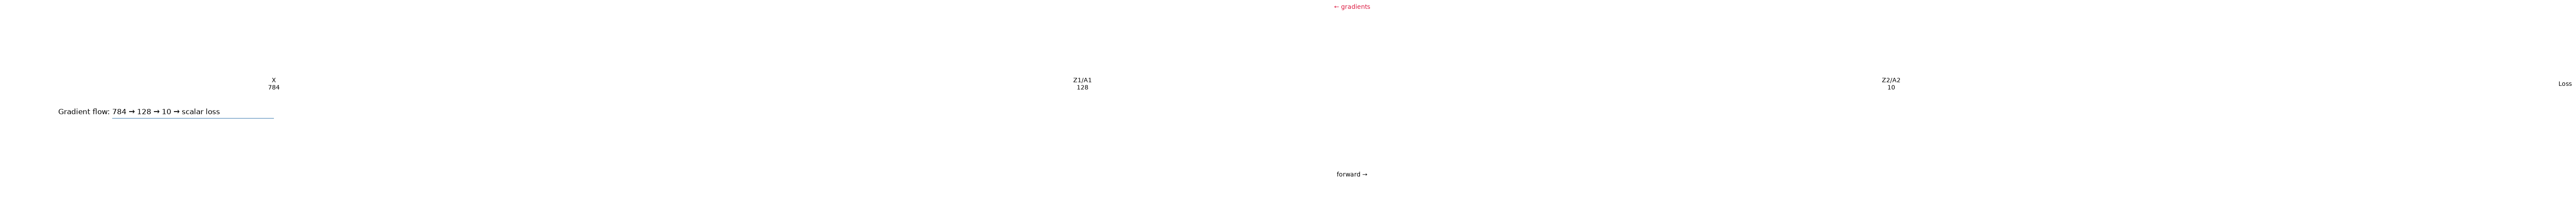

In [9]:
# Gradient flow diagram
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.axis('off')
layers = [('X\n784', 1), ('Z1/A1\n128', 4), ('Z2/A2\n10', 7), ('Loss', 9.5)]
for label, x in layers:
    ax.add_patch(plt.Rectangle((x - 0.6, 1), 1.2, 0.8, fill=False, ec='steelblue'))
    ax.text(x, 1.4, label, ha='center', va='center', fontsize=10)
for i in range(len(layers) - 1):
    ax.annotate('', xy=(layers[i+1][1] - 0.65, 1.4), xytext=(layers[i][1] + 0.65, 1.4),
                arrowprops=dict(arrowstyle='->', lw=1.5))
ax.text(5, 0.3, 'forward →', ha='center')
ax.text(5, 2.3, '← gradients', ha='center', color='crimson')
ax.set_title('Gradient flow: 784 → 128 → 10 → scalar loss')
plt.tight_layout()
plt.show()

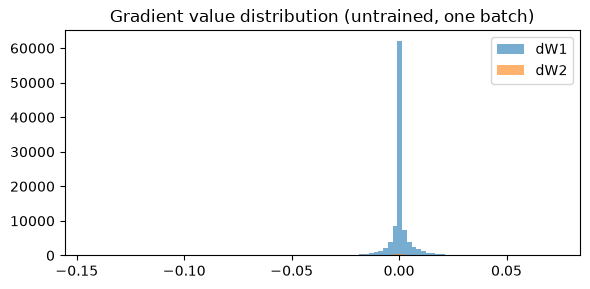

In [10]:
# Histogram of gradient norms per layer (one batch)
dW1, db1, dW2, db2 = grads
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(dW1.ravel(), bins=40, alpha=0.6, label='dW1')
ax.hist(dW2.ravel(), bins=40, alpha=0.6, label='dW2')
ax.set_title('Gradient value distribution (untrained, one batch)')
ax.legend()
plt.tight_layout()
plt.show()

### Pause & Reflect — Backpropagation

1. Why is $\delta^{[2]} = A^{[2]} - Y$ the same form as XOR?
2. What happens to $\delta^{[1]}$ for a neuron where $Z^{[1]} \leq 0$?
3. Why average gradients over the batch size?

### Discussion — Backpropagation

1. **Same form**: Softmax+CE is the multi-class generalization of sigmoid+BCE — the Jacobian simplifies to prediction minus target.
2. **Dead ReLU**: Mask is 0 — neuron gets **no gradient** that step (can "die" if always inactive).
3. **Batch average**: Stabilizes step size; mini-batch gradient is an unbiased estimate of the full-data gradient.

## 6. Training loop (mini-batch SGD)

Each epoch shuffles training data and processes mini-batches of size 64.

In [11]:
def accuracy(X, y, W1, b1, W2, b2):
    A2, _ = forward(X, W1, b1, W2, b2)
    preds = np.argmax(A2, axis=1)
    return np.mean(preds == y)

def iterate_minibatches(X, Y, batch_size, rng):
    n = X.shape[0]
    indices = rng.permutation(n)
    for start in range(0, n, batch_size):
        batch_idx = indices[start:start + batch_size]
        yield X[batch_idx], Y[batch_idx]

def train(X_train, Y_train, X_test, y_test, epochs=EPOCHS, lr=LEARNING_RATE, batch_size=BATCH_SIZE):
    W1, b1, W2, b2 = init_params()
    train_losses, test_accs = [], []
    train_rng = np.random.default_rng(42)

    for epoch in range(1, epochs + 1):
        epoch_loss = 0.0
        n_batches = 0
        for Xb, Yb in iterate_minibatches(X_train, Y_train, batch_size, train_rng):
            A2, cache = forward(Xb, W1, b1, W2, b2)
            loss = compute_loss(Yb, A2)
            epoch_loss += loss
            n_batches += 1
            dW1, db1, dW2, db2 = backward(Xb, Yb, cache, W2)
            W1 -= lr * dW1
            b1 -= lr * db1
            W2 -= lr * dW2
            b2 -= lr * db2
        train_losses.append(epoch_loss / n_batches)
        test_accs.append(accuracy(X_test, y_test, W1, b1, W2, b2))
        if epoch % 5 == 0 or epoch == 1:
            print(f'Epoch {epoch:2d}  loss={train_losses[-1]:.4f}  test_acc={test_accs[-1]*100:.1f}%')

    return W1, b1, W2, b2, train_losses, test_accs

W1, b1, W2, b2, train_losses, test_accs = train(X_train, Y_train, X_test, y_test)
final_acc = test_accs[-1]
print(f'\nFinal test accuracy: {final_acc * 100:.1f}%')

Epoch  1  loss=0.5318  test_acc=74.5%
Epoch  5  loss=0.0787  test_acc=95.5%
Epoch 10  loss=0.0171  test_acc=95.9%
Epoch 15  loss=0.0057  test_acc=96.2%
Epoch 20  loss=0.0034  test_acc=96.2%
Epoch 25  loss=0.0024  test_acc=96.0%

Final test accuracy: 96.0%


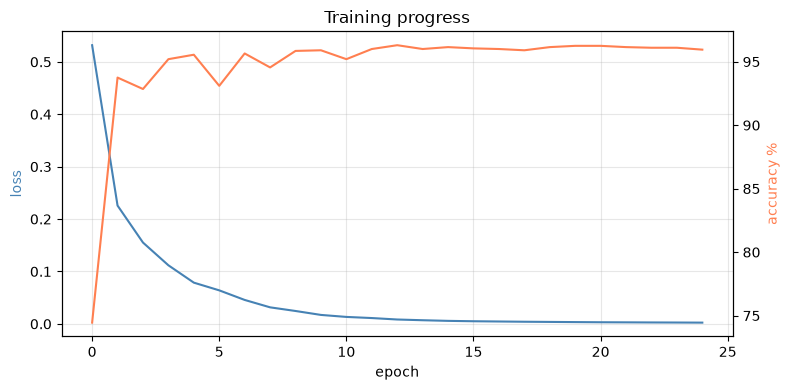

In [12]:
fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
ax1.plot(train_losses, color='steelblue', label='train loss')
ax2.plot([a * 100 for a in test_accs], color='coral', label='test accuracy %')
ax1.set_xlabel('epoch')
ax1.set_ylabel('loss', color='steelblue')
ax2.set_ylabel('accuracy %', color='coral')
ax1.set_title('Training progress')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

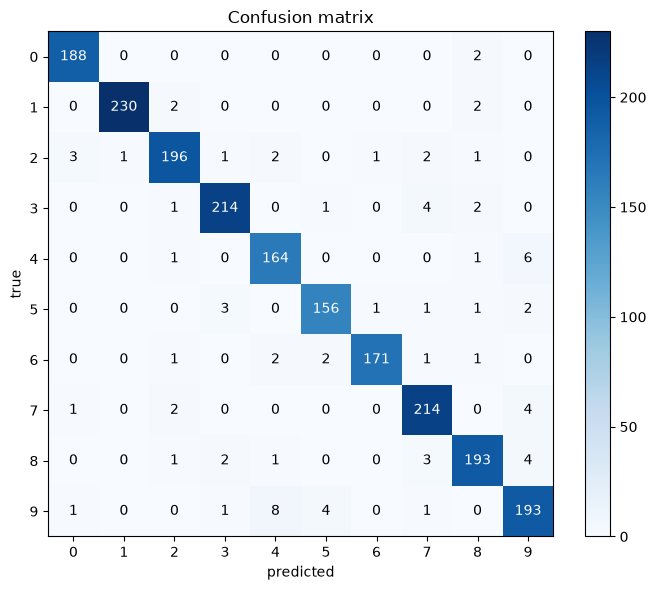

In [13]:
# Confusion matrix
A2_test, _ = forward(X_test, W1, b1, W2, b2)
preds = np.argmax(A2_test, axis=1)
num_classes = 10
cm = np.zeros((num_classes, num_classes), dtype=int)
for t, p in zip(y_test, preds):
    cm[t, p] += 1

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xlabel('predicted')
ax.set_ylabel('true')
ax.set_title('Confusion matrix')
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='k' if cm[i, j] < cm.max()/2 else 'w')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

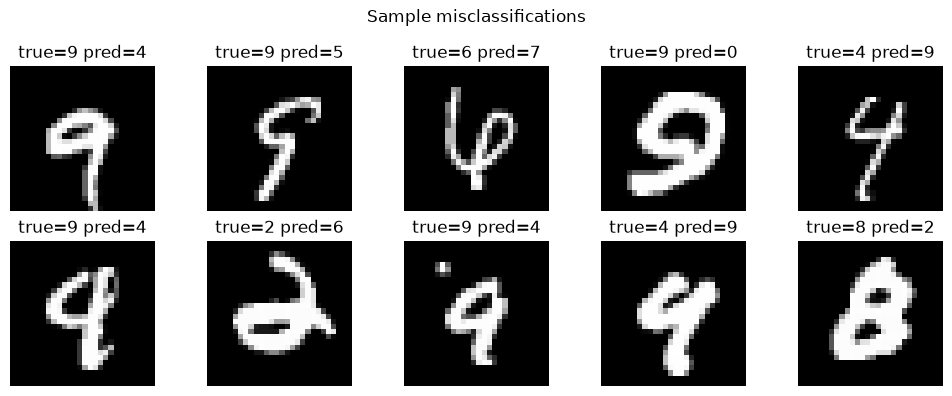

In [14]:
# Misclassified examples
wrong = np.where(preds != y_test)[0]
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, i in zip(axes.ravel(), wrong[:10]):
    ax.imshow(X_test[i].reshape(28, 28), cmap='gray')
    ax.set_title(f'true={y_test[i]} pred={preds[i]}')
    ax.axis('off')
plt.suptitle('Sample misclassifications')
plt.tight_layout()
plt.show()

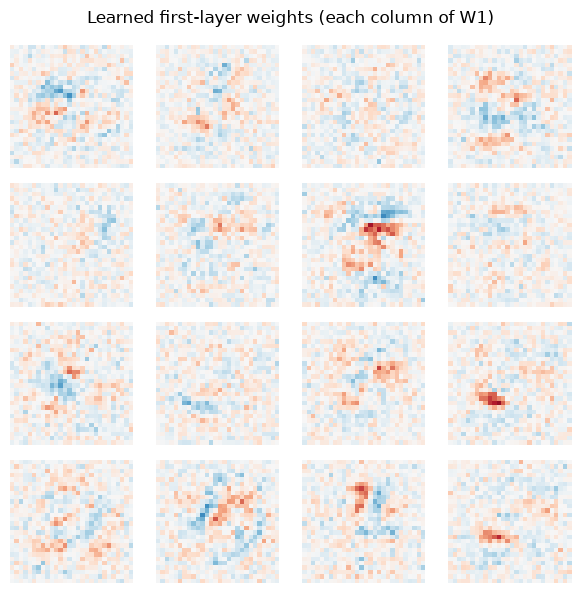

In [15]:
# First-layer weights as 28x28 "stroke" images (16 neurons)
n_show = 16
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for ax, i in zip(axes.ravel(), range(n_show)):
    ax.imshow(W1[:, i].reshape(28, 28), cmap='RdBu', vmin=-0.5, vmax=0.5)
    ax.axis('off')
plt.suptitle('Learned first-layer weights (each column of W1)')
plt.tight_layout()
plt.show()

### Pause & Reflect — Training

1. Why might test accuracy wobble epoch-to-epoch even as loss decreases?
2. What would you expect if `LEARNING_RATE` were 10x larger?
3. Why is mini-batch faster per epoch than full-batch for 60k images?

### Discussion — Training

1. **Accuracy wobble**: Accuracy is a **step function** of weights; small loss improvements can cross decision thresholds unpredictably.
2. **Large LR**: Overshooting minima — loss spikes or divergence; weights oscillate.
3. **Mini-batch**: More weight updates per epoch ($\lceil N / B \rceil$ steps) and better memory locality than one giant matrix multiply.

## 7. PyTorch comparison

`nn.CrossEntropyLoss` expects **raw logits** (no softmax in the model) — it applies log-softmax + NLL internally.

In [16]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)

X_tr_t = torch.tensor(X_train, dtype=torch.float32)
y_tr_t = torch.tensor(y_train, dtype=torch.long)
X_te_t = torch.tensor(X_test, dtype=torch.float32)
y_te_t = torch.tensor(y_test, dtype=torch.long)

loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=BATCH_SIZE, shuffle=True)

torch_model = nn.Sequential(
    nn.Linear(784, HIDDEN_SIZE),
    nn.ReLU(),
    nn.Linear(HIDDEN_SIZE, 10),  # logits only
)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(torch_model.parameters(), lr=LEARNING_RATE)

torch_test_accs = []
for epoch in range(1, EPOCHS + 1):
    torch_model.train()
    for xb, yb in loader:
        optimizer.zero_grad()
        logits = torch_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
    torch_model.eval()
    with torch.no_grad():
        logits = torch_model(X_te_t)
        pred = logits.argmax(dim=1)
        acc = (pred == y_te_t).float().mean().item()
    torch_test_accs.append(acc)
    if epoch % 5 == 0 or epoch == 1:
        print(f'PyTorch epoch {epoch:2d}  test_acc={acc*100:.1f}%')

print(f'\nNumPy final acc: {final_acc*100:.1f}%  |  PyTorch final acc: {torch_test_accs[-1]*100:.1f}%')

PyTorch epoch  1  test_acc=82.7%
PyTorch epoch  5  test_acc=91.9%
PyTorch epoch 10  test_acc=96.1%
PyTorch epoch 15  test_acc=96.4%
PyTorch epoch 20  test_acc=96.1%
PyTorch epoch 25  test_acc=96.2%

NumPy final acc: 96.0%  |  PyTorch final acc: 96.2%


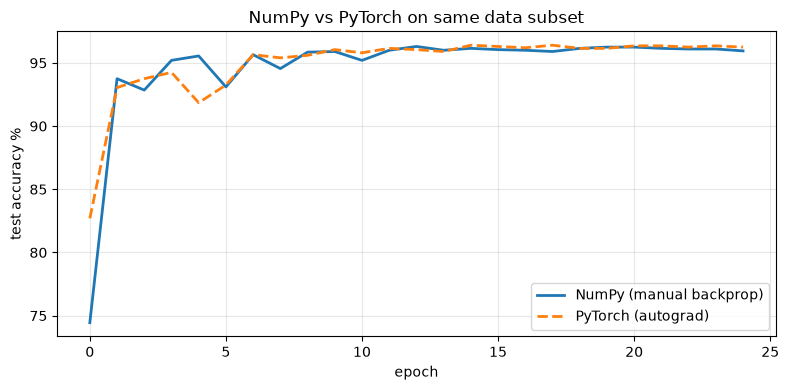

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot([a * 100 for a in test_accs], label='NumPy (manual backprop)', linewidth=2)
ax.plot([a * 100 for a in torch_test_accs], label='PyTorch (autograd)', linewidth=2, linestyle='--')
ax.set_xlabel('epoch')
ax.set_ylabel('test accuracy %')
ax.legend()
ax.set_title('NumPy vs PyTorch on same data subset')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

| Concept | XOR notebook | MNIST notebook |
|---------|--------------|----------------|
| Output activation | Sigmoid | Softmax |
| Loss | Binary CE | Categorical CE |
| Hidden activation | Sigmoid | ReLU |
| Batch | Full (4) | Mini-batch (64) |
| Key backprop insight | $\delta = \hat{Y} - Y$ | Same, plus ReLU mask |

**Production next steps:** GPU, Adam optimizer, deeper nets / CNNs, full 60k dataset, data augmentation.